# **Projeto Semantix - Sistema de Detecção de Fraude **

In [55]:
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# 1. Carrega a base de dados, verifique os tipos de dados e os dados faltantes.


As variáveis country, merchant_category e transaction_type tiveram seus tipos convertidos de object para string. Além disso, foi realizada a padronização do formato dos textos nas colunas merchant_category e transaction_type, ajustando o uso de letras (ex: todas em maiúsculo). Durante a análise, não foram identificados valores nulos no conjunto de dados.

In [56]:
# Carregando a Base de dados
df = pd.read_csv('synthetic_fraud_dataset.csv', delimiter=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [57]:
# Transformando o tipo da coluna em str
df['transaction_type'] = df['transaction_type'].astype('string')
df['merchant_category'] = df['merchant_category'].astype('string')
df['country'] = df['country'].astype('string')


In [58]:
df

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0
...,...,...,...,...,...,...,...,...,...,...
9995,1076,482,58.366442,POS,Clothing,DE,12,0.066366,0.086344,0
9996,4995,904,139.502160,POS,Travel,DE,13,0.119014,0.285680,0
9997,3485,527,71.012122,Online,Travel,TR,8,0.119204,0.262262,0
9998,7922,771,21.031405,QR,Grocery,UK,12,0.027088,0.295243,0


In [59]:
df['country'].unique()

<StringArray>
['TR', 'US', 'FR', 'DE', 'UK', 'NG']
Length: 6, dtype: string

In [60]:
df['merchant_category'].unique()

<StringArray>
['Travel', 'Food', 'Clothing', 'Grocery', 'Electronics']
Length: 5, dtype: string

In [61]:
df['transaction_type'].unique()


<StringArray>
['ATM', 'QR', 'Online', 'POS']
Length: 4, dtype: string

In [62]:
df['merchant_category'] = df['merchant_category'].str.lower()
df['transaction_type'] = df['transaction_type'].str.lower()
df['country'] = df['country'].str.lower()

In [63]:
df

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,atm,travel,tr,12,0.992347,0.947908,1
1,456,692,48.018303,qr,food,us,21,0.168571,0.224057,0
2,4747,587,136.881960,online,travel,tr,14,0.296127,0.125058,0
3,6934,445,80.534719,pos,clothing,tr,23,0.124801,0.159243,0
4,1646,729,120.041158,online,grocery,fr,16,0.098129,0.027542,0
...,...,...,...,...,...,...,...,...,...,...
9995,1076,482,58.366442,pos,clothing,de,12,0.066366,0.086344,0
9996,4995,904,139.502160,pos,travel,de,13,0.119014,0.285680,0
9997,3485,527,71.012122,online,travel,tr,8,0.119204,0.262262,0
9998,7922,771,21.031405,qr,grocery,uk,12,0.027088,0.295243,0


# 2. Analise de outliers.

A coluna amount foi inicialmente avaliada como potencial outlier. No entanto, ao analisá-la em conjunto com a variável de fraude, observou-se que valores mais altos estão, em sua maioria, associados a um maior risco de fraude. Dessa forma, esses valores representam um comportamento relevante do problema e, por isso, não será realizado tratamento ou remoção de outliers nessa coluna.

In [64]:
df.describe()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000


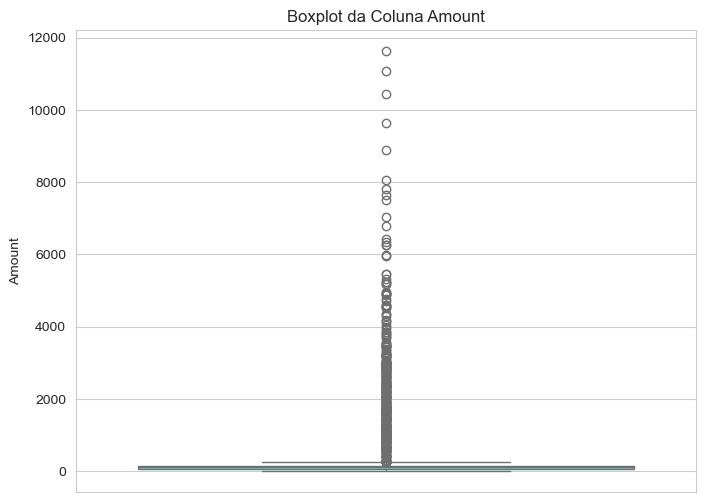

In [65]:
# Gráfico Boxplot coluna Amount
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='amount', color= 'skyblue')
plt.title('Boxplot da Coluna Amount')
plt.ylabel('Amount')
plt.show()

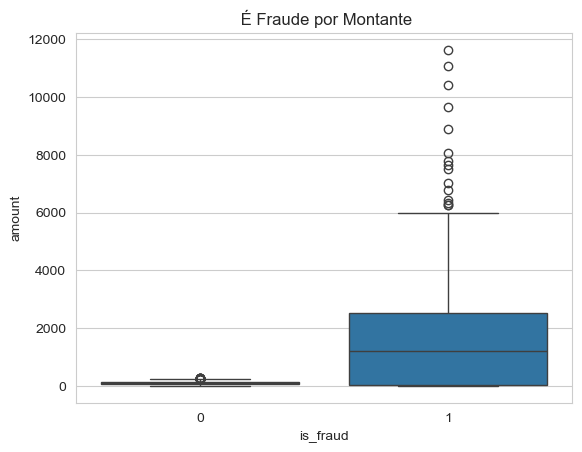

In [66]:
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title(' É Fraude por Montante')
plt.show()

# 3. Análise Univariada e Bivariada. Transformação de colunas categoricas em númericas.

Observou-se que aproximadamente 88% das transações não são fraudulentas, indicando um conjunto de dados desbalanceado. Em relação aos países, a distribuição é relativamente homogênea, com exceção da Nigéria (NG), que representa menos de 2% das transações; no entanto, todas as transações provenientes desse país foram classificadas como fraude. Além disso, as variáveis transaction_type e merchant_category apresentam uma distribuição equilibrada, sem concentração significativa em categorias específicas.

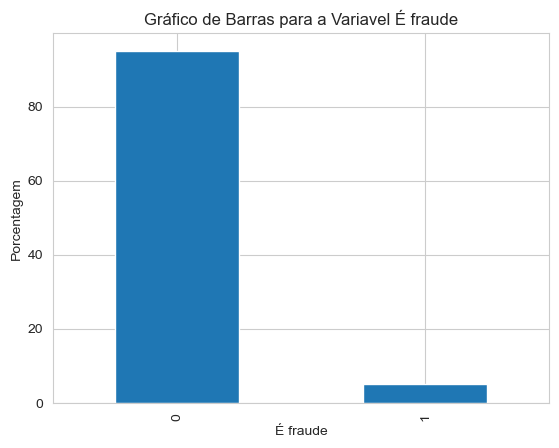

In [67]:
#contagem da coluna binaryClass
contagem_is_fraud = df['is_fraud'].value_counts()

porcentagem_is_fraud = (contagem_is_fraud/ contagem_is_fraud.sum()) * 100
ax = porcentagem_is_fraud.plot(kind='bar')
plt.title('Gráfico de Barras para a Variavel É fraude')
plt.xlabel('É fraude')
plt.ylabel('Porcentagem')
plt.show()

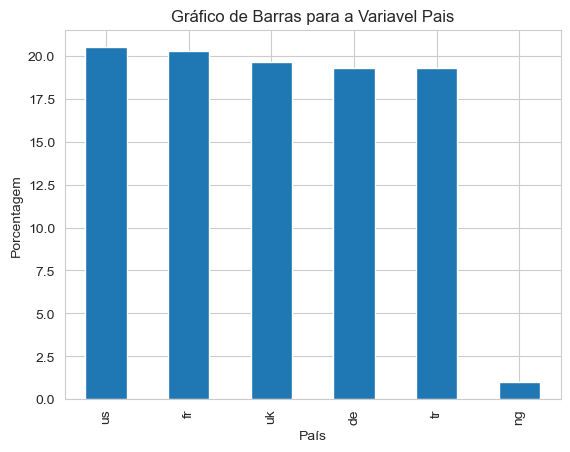

In [68]:
#contagem da coluna country
contagem_country = df['country'].value_counts()

porcentagem_country = (contagem_country/ contagem_country.sum()) * 100
ax = porcentagem_country.plot(kind='bar')
plt.title('Gráfico de Barras para a Variavel Pais')
plt.xlabel('País')
plt.ylabel('Porcentagem')
plt.show()

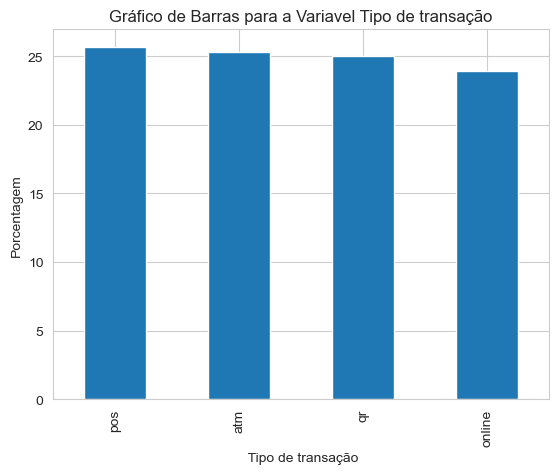

In [69]:
#contagem da coluna country
contagem_transaction_type = df['transaction_type'].value_counts()

porcentagem_transaction_type = (contagem_transaction_type/ contagem_transaction_type.sum()) * 100
ax = porcentagem_transaction_type.plot(kind='bar')
plt.title('Gráfico de Barras para a Variavel Tipo de transação')
plt.xlabel(' Tipo de transação')
plt.ylabel('Porcentagem')
plt.show()

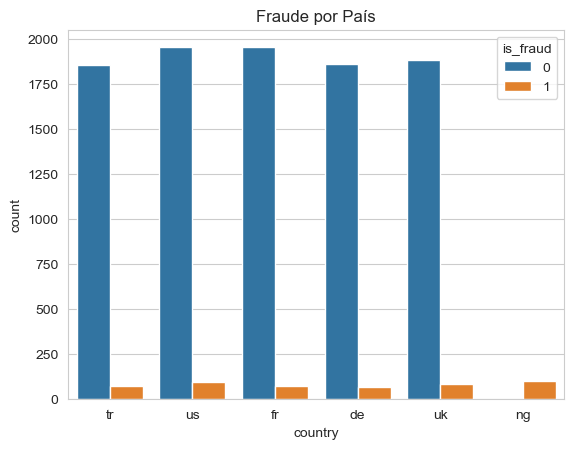

In [70]:
#Seu código aqui
sns.countplot(x='country', hue='is_fraud', data=df)
plt.title('Fraude por País')
plt.show()

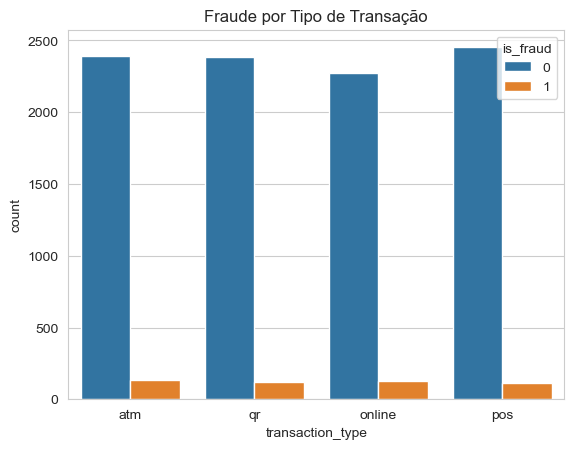

In [71]:
#Seu código aqui
sns.countplot(x='transaction_type', hue='is_fraud', data=df)
plt.title('Fraude por Tipo de Transação')
plt.show()

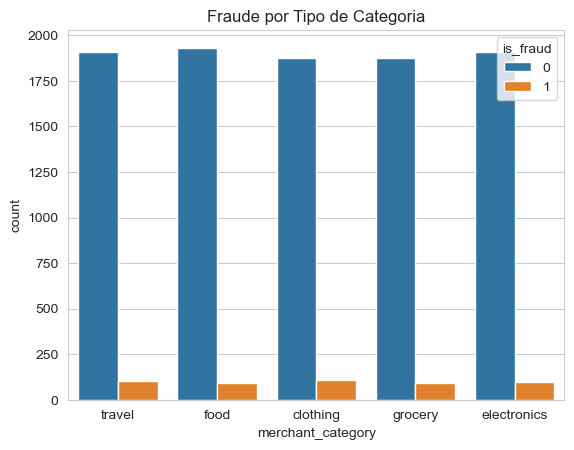

In [72]:
#Seu código aqui
sns.countplot(x='merchant_category', hue='is_fraud', data=df)
plt.title('Fraude por Tipo de Categoria')
plt.show()

In [73]:
df = pd.get_dummies(df, columns=['transaction_type'], prefix='transaction_type')
df = pd.get_dummies(df, columns=['merchant_category'], prefix='merchant_category')
df = pd.get_dummies(df, columns=['country'], prefix='country')


In [74]:
for column in df.columns:
    if df[column].dtype == 'boolean':
        df[column] = df[column].astype(int)

In [75]:
df

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud,transaction_type_atm,transaction_type_online,transaction_type_pos,...,merchant_category_electronics,merchant_category_food,merchant_category_grocery,merchant_category_travel,country_de,country_fr,country_ng,country_tr,country_uk,country_us
0,9608,363,4922.587542,12,0.992347,0.947908,1,1,0,0,...,0,0,0,1,0,0,0,1,0,0
1,456,692,48.018303,21,0.168571,0.224057,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,4747,587,136.881960,14,0.296127,0.125058,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3,6934,445,80.534719,23,0.124801,0.159243,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,1646,729,120.041158,16,0.098129,0.027542,0,0,1,0,...,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1076,482,58.366442,12,0.066366,0.086344,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
9996,4995,904,139.502160,13,0.119014,0.285680,0,0,0,1,...,0,0,0,1,1,0,0,0,0,0
9997,3485,527,71.012122,8,0.119204,0.262262,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
9998,7922,771,21.031405,12,0.027088,0.295243,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0


# 4. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

Foram removidas as colunas transaction_id e user_id, por não contribuírem para o desempenho do modelo. A análise de correlação indicou que as variáveis com maior relação com a variável alvo (is_fraud) são device_risk_score (0,87), ip_risk_score (0,87), amount (0,64) e country_NG (0,44).

In [76]:
df = df.drop(columns=['transaction_id', 'user_id'])

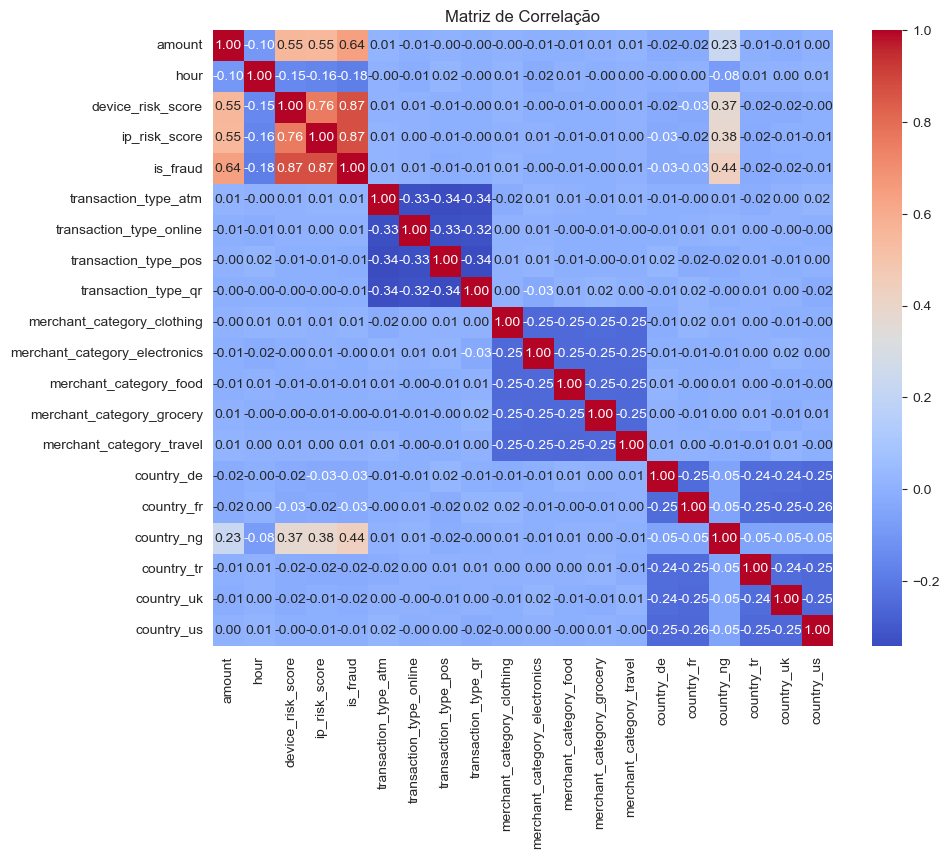

In [77]:
# Matriz de correlação
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

# 5. Faça a separação da base em X e Y e em seguida nas bases de treino e teste. Tambem faça a padronização dos dados. 

In [78]:
# Remoção de variáveis que estavam influenciando demais o modelo e prejudicando os resultados.
df = df.drop(columns=['device_risk_score', 'ip_risk_score','country_ng'])

In [79]:
# Separando as bases X e Y
X = df.drop(columns=['is_fraud'])
Y = df['is_fraud']

In [80]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [101]:
# Padronizando os Dados
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# 6. Coloque Hiperparametros e Treine o modelo XGBoost com sua base de treino.

In [82]:
model_xgboost = xgb.XGBClassifier()
model_xgboost.objective

'binary:logistic'

In [103]:
model_xgboost = xgb.XGBClassifier( max_depth=4).fit(X_train_scaled, Y_train)

In [104]:
# Colocando hiperparametros

param_grid_xgb = {
    'n_estimators': [1,5,10,50,100],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}

random_search_xgb = RandomizedSearchCV( estimator=model_xgboost,
                           param_distributions=param_grid_xgb,
                           n_iter=50,
                           scoring='f1', 
                           cv=3, 
                           verbose=2, 
                           n_jobs=-1)


random_search_xgb.fit(X_train_scaled, Y_train)


Fitting 3 folds for each of 50 candidates, totalling 150 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,50
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [105]:
best_params_xgb = random_search_xgb.best_params_
best_xgb_model = random_search_xgb.best_estimator_

In [106]:
print("Melhores hiperparâmetros encontrados:", best_params_xgb)

Melhores hiperparâmetros encontrados: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}


In [107]:
Y_train_pred = best_xgb_model.predict(X_train_scaled)

In [108]:
relatorio = classification_report(Y_train, Y_train_pred)
print("Relatório de Classificação com o Melhor Modelo de Treino:")
print(relatorio)

Relatório de Classificação com o Melhor Modelo de Treino:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7611
           1       0.99      0.98      0.98       389

    accuracy                           1.00      8000
   macro avg       1.00      0.99      0.99      8000
weighted avg       1.00      1.00      1.00      8000



In [109]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(Y_train, Y_train_pred))

[[7608    3]
 [   9  380]]


# 7. Realize as previsões para a base de teste e traga a avaliação.

Para melhorar a generalização do modelo, foram removidas as variáveis device_risk_score, ip_risk_score e country_ng, pois estavam influenciando muito os resultados e facilitando a predição.
Em seguida, foi utilizado o RandomizedSearchCV para testar diferentes combinações de hiperparâmetros, buscando uma configuração mais eficiente de forma mais rápida. Com esses ajustes, o modelo apresentou ótimo desempenho.
Na base de treino, alcançou 100% de acurácia. Para a classe 0, teve 100% de precisão, recall e f1-score. Já para a classe 1, obteve precisão de 99%, recall de 98% e f1-score de 98%.
Na base de teste, também atingiu 100% de acurácia. A classe 0 manteve 100% em todas as métricas, enquanto a classe 1 apresentou precisão de 98%, recall de 96% e f1-score de 97%, mostrando boa capacidade de identificar fraudes com poucos erros.

In [123]:
Y_pred = best_xgb_model.predict(X_test_scaled)

In [124]:
#SEU CÓDIGO AQUI
relatorio = classification_report(Y_test, Y_pred)
print("Relatório de Classificação com o Melhor Modelo de Teste:")
print(relatorio)

Relatório de Classificação com o Melhor Modelo de Teste:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1889
           1       0.98      0.96      0.97       111

    accuracy                           1.00      2000
   macro avg       0.99      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [125]:
print(confusion_matrix(Y_test, Y_pred))

[[1887    2]
 [   4  107]]


# 8. Treine o modelo Random Forest com sua base de treino + realize as previsões e avalições.

O modelo Random Forest apresentou acurácia de 100% tanto no treino quanto no teste. Para a classe 0, os resultados foram perfeitos em ambos os conjuntos, com precisão, recall e f1-score iguais a 100%.
Já para a classe 1, houve uma leve melhora no conjunto de teste em relação ao treino: a precisão passou de 98% para 100%, o recall de 96% para 98% e o f1-score de 97% para 99%. Isso indica um bom desempenho do modelo na identificação de fraudes, com resultados consistentes entre treino e teste.


In [113]:
rf_model = RandomForestClassifier(random_state=42,
    class_weight='balanced')

In [114]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [115]:
# Configurando o Randomized Search
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid,
                                   n_iter=100, cv=5, n_jobs=-1, verbose=2, random_state=42, scoring='f1')


In [116]:
random_search.fit(X_train_scaled, Y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,100
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [117]:
best_params_random = random_search.best_params_
print(f"Melhores Hiperparâmetros: {best_params_random}")

Melhores Hiperparâmetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10}


In [118]:
# Treinando o modelo com os melhores hiperparâmetros encontrados acima
best_rf_model = random_search.best_estimator_
best_rf_model.fit(X_train, Y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [119]:
# Fazendo previsões no conjunto de treino
Y_pred_train = best_rf_model.predict(X_train)

In [120]:
# Avaliando o modelo Random Forest
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação Random Forest - Treino:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 1.00
Relatório de Classificação Random Forest - Treino:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1889
           1       0.98      0.96      0.97       111

    accuracy                           1.00      2000
   macro avg       0.99      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Matriz de Confusão:
 [[1887    2]
 [   4  107]]


In [121]:
# Fazendo previsões no conjunto de teste
Y_pred = best_rf_model.predict(X_test)

In [122]:
# Avaliando o modelo Random Forest
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação Random Forest - Teste:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 1.00
Relatório de Classificação Random Forest - Teste:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1889
           1       1.00      0.98      0.99       111

    accuracy                           1.00      2000
   macro avg       1.00      0.99      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Matriz de Confusão:
 [[1889    0]
 [   2  109]]


# 9. Qual modelo se saiu melhor? O SVM ou Regresão Logistica?

Os dois modelos apresentaram ótimo desempenho na previsão dos dados. Ambos atingiram 100% de precisão, recall e f1-score para a classe 0.
Na classe 1, o modelo Random Forest se destacou, com 100% de precisão, 98% de recall e f1-score de 99%, enquanto o XGBoost obteve 98% de precisão, 96% de recall e f1-score de 97%.
Dessa forma, o Random Forest foi o melhor modelo, pois conseguiu evitar falsos positivos e deixou de identificar apenas 2 casos de fraude, alcançando cerca de 98% de detecção das fraudes.